# Multi-Factor Equity Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wuyule999bian/multi-factor-equity-model/blob/main/notebooks/multi_factor_equity_model.ipynb)

A cross-sectional, Fama-French-style factor investing model built on ~190 US
large/mid-cap equities: **value, momentum, size, and quality** factors,
independently decile-sorted and long-short backtested, a two-pass
**Fama-MacBeth** cross-sectional regression estimating each factor's risk
premium (benchmarked against the **Kenneth French Data Library**), and a
composite z-score portfolio decomposed back into its factor exposures.

This notebook is the single source of truth for the project: it runs
top-to-bottom with no manual edits, in Google Colab or locally, after you
supply one Financial Modeling Prep (FMP) API key. See `README.md` for setup,
methodology, and an honest accounting of this project's limitations (universe
size, data vendor quirks, simplifying assumptions) -- several of which are
also called out inline below, exactly where they matter.

> **TODO (repo owner):** replace `wuyule999bian/multi-factor-equity-model` above with your actual
> `github-username/repo-name` once this is pushed, so the "Open in Colab"
> badge resolves.


## Setup

Works two ways:
- **Colab**: this cell clones the repo (so `src/` and `data/universe.csv`
  exist) and installs dependencies.
- **Local**: assumes you've already run `git clone` + `pip install -r
  requirements.txt` yourself (see README) -- this cell just locates the repo
  root and skips straight to importing.


In [1]:
# Standard library imports for system path, OS operations, and running shell commands.
import sys, os, subprocess
from pathlib import Path

# Check if the notebook is running in Google Colab.
IN_COLAB = "google.colab" in sys.modules
# URL of the GitHub repository containing the project files.
REPO_URL = "https://github.com/wuyule999bian/multi-factor-equity-model.git"
# Name of the repository directory once cloned.
REPO_DIR = "multi-factor-equity-model"

if IN_COLAB:
    # If in Colab, clone the repository if it doesn't already exist.
    if not Path(REPO_DIR).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    # Change the current working directory to the cloned repository.
    os.chdir(REPO_DIR)
    # Install Python dependencies listed in requirements.txt silently.
    %pip install -q -r requirements.txt
else:
    # If running locally, check if the notebook is in a subdirectory (e.g., 'notebooks/').
    # If so, move up to the repository root to ensure relative paths work.
    if not Path("src").exists() and Path(".." + os.sep + "src").exists():
        os.chdir("..")
    # Assert that the 'src' directory and 'data/universe.csv' exist, indicating we're at the repo root.
    assert Path("src").exists() and Path("data/universe.csv").exists(), (
        "Could not locate the repo root. Run this notebook from inside the "
        "cloned repo, or run `pip install -r requirements.txt` yourself."
    )

# Add the 'src' directory to the Python system path so modules can be imported.
sys.path.insert(0, "src")
# Print the current working directory for verification.
print("Working directory:", Path.cwd())

Working directory: /content/multi-factor-equity-model


In [2]:
# Import numerical computing library.
import numpy as np
# Import data manipulation and analysis library.
import pandas as pd
# Import plotting library.
import matplotlib.pyplot as plt

# Import custom modules from the 'src' directory.
import data, factors, portfolios, regression, viz

# Set the visualization style using the custom 'viz' module.
viz.set_style()

# Define the base directory for data files, relative to the notebook's working directory.
# This ensures portability between Colab and local environments.
DATA_DIR = "./data"
# Create a 'raw' subdirectory within DATA_DIR if it doesn't already exist.
# This is where raw fetched data will be cached.
Path(DATA_DIR, "raw").mkdir(parents=True, exist_ok=True)

## Point-in-time hygiene (read this before the results)

Two failure modes wreck a factor backtest silently: **lookahead** (using
information before it was actually public) and **survivorship bias**
(only including names that happened to survive to today). Here's exactly
what this project does about each, discovered and locked in while building
the data pipeline against a real, rate-limited free-tier API key:

**Lookahead.** FMP's free tier does not expose SEC filing dates on the
`key-metrics`/`ratios` endpoints, so we can't look up the exact date each
fundamental became public. Instead, every fundamental row -- whether it
came from FMP or the yfinance fallback (see below) -- is stamped
`available_date = fiscal_period_end + 90 calendar days`, a deliberately
conservative pad past the ~60-75 day 10-K deadline large caps typically
meet. Rebalance dates are then fixed at **July 1 of the year after** each
fiscal year, which is guaranteed to fall after `available_date` for every
ticker regardless of individual fiscal calendars (checked programmatically
in `factors.assign_rebalance_period`, which drops any row that fails this
check). Momentum and forward returns are read directly off the price panel
at those same rebalance dates -- never from a date the fundamentals data
wouldn't have supported.

**Survivorship bias.** The universe (`data/universe.csv`) is a **static,
hand-picked list of ~190 large/mid-cap tickers as of today**, applied
retroactively across the whole backtest window -- not a point-in-time
historical index membership list. That means companies that were removed
from major indices for underperforming, or went bankrupt, are absent from
the backtest entirely, which biases results upward. This is a real
limitation of not having point-in-time index constituent data (e.g. CRSP),
not an oversight -- it's called out again in the README. Within the static
universe itself, however, no ticker is dropped for having a bad period: a
name with a terrible ROE or a big drawdown stays in every cross-section it
has data for.

**A vendor quirk that shaped the design.** Probing FMP's free-tier key
against ~200 candidate tickers before committing to this pipeline showed it
whitelists only a minority of symbols (mostly the largest, most-traded
names) for `key-metrics`/`ratios` -- everything else returns HTTP 402. A
100+ name cross-sectional study isn't possible on FMP alone at this tier.
So fundamentals are sourced **FMP-first, yfinance-fallback**: every ticker
FMP will serve uses FMP's properly-computed ratios; every ticker it won't
gets the same fields reconstructed from yfinance's raw income
statement/balance sheet plus our own price panel (point-in-time market cap
= reported shares outstanding x price on the fiscal date). Each row carries
a `source` column so this is visible in the data, not hidden by it.


## Step 1: Universe & data acquisition

Pulls (and caches to `data/raw/`, so reruns are instant and don't re-hit
either API):
- **Universe**: ~190 US equities across 10 GICS sectors (`data/universe.csv`).
- **Prices**: full daily history via yfinance (no key needed).
- **Fundamentals**: 5 years of annual data per ticker, FMP-first with a
  yfinance fallback (see above).

Your FMP key is resolved from Colab secrets, then the `FMP_API_KEY`
environment variable, then an interactive prompt as a last resort -- it is
never hardcoded or written to any file in this repo.


In [3]:
# Retrieve the FMP API key, attempting from Colab secrets, then environment variables, then interactive prompt.
FMP_API_KEY = data.get_fmp_api_key()

# Load the universe of tickers from the specified data directory.
universe = data.load_universe(DATA_DIR)
# Print the number of tickers and unique sectors in the loaded universe.
print(f"Universe: {len(universe)} tickers across {universe['sector'].nunique()} sectors")
# Display the count of tickers per sector.
universe["sector"].value_counts()

Enter your Financial Modeling Prep API key: ··········
Universe: 192 tickers across 10 sectors


,count
sector,
Consumer Discretionary,20
Health Care,20
Materials,20
Financials,20
Information Technology,20
Industrials,20
Utilities,20
Consumer Staples,19
Energy,18


In [4]:
# Fetch historical price data for all tickers in the universe.
# The 'start' date is chosen to cover the lookback period for momentum calculations.
# 'end' is set to today's date for current data.
# Data is cached in DATA_DIR.
prices = data.fetch_prices(
    universe["ticker"].tolist(), start="2020-06-01", end=pd.Timestamp.today().strftime("%Y-%m-%d"),
    data_dir=DATA_DIR,
)
# Print the shape of the resulting price panel (trading days x tickers).
print(f"Price panel: {prices.shape[0]} trading days x {prices.shape[1]} tickers")
# Display the last 3 rows and first 5 columns of the price DataFrame to inspect its structure and data.
prices.iloc[-3:, :5]

Price panel: 1547 trading days x 192 tickers


Ticker,AAPL,ABBV,ABT,ACN,ADBE
Date,,,,,
2026-07-24,333.019989,259.359985,103.059998,146.990005,225.110001
2026-07-27,336.910004,256.910004,104.489998,154.059998,237.750000
2026-07-28,340.079987,263.200012,107.269997,164.660004,249.179993


In [5]:
# Build the fundamentals panel by fetching financial statements and ratios.
# It uses FMP_API_KEY for FMP data and falls back to yfinance if FMP data is unavailable.
# The 'prices' DataFrame is used for market cap calculations where yfinance is the source.
# 'sleep_sec' adds a delay between API calls to respect rate limits.
fundamentals = data.build_fundamentals_panel(universe, FMP_API_KEY, prices, DATA_DIR, sleep_sec=0.2)
# Print the shape of the fundamentals panel and the number of unique tickers included.
print(f"\nFundamentals panel: {fundamentals.shape[0]} (ticker, fiscal-year) rows, "
      f"{fundamentals['ticker'].nunique()} tickers")
# Display the first few rows of the fundamentals DataFrame, showing key columns like ticker, sector, fiscal date,
# available date, market cap, and data source.
fundamentals[["ticker", "sector", "fiscal_date", "available_date", "marketCap", "source"]].head()

    (rate limited, retry 1/2 in 2s)
    (rate limited, retry 2/2 in 4s)
    (still rate limited after 2 retries, falling back) https://financialmodelingprep.com/stable/key-metrics
    (FMP rate limit circuit open -- switching to yfinance for the rest of this run)
  [102/192] ISRG: no fundamentals from either source, skipping
Fundamentals sourced: 0 from FMP, 191 from yfinance, 1 skipped entirely

Fundamentals panel: 764 (ticker, fiscal-year) rows, 191 tickers


,ticker,sector,fiscal_date,available_date,marketCap,source
0,AAPL,Information Technology,2022-09-30,2022-12-29,2.163021e+12,yfinance
1,AAPL,Information Technology,2023-09-30,2023-12-29,2.629064e+12,yfinance
2,AAPL,Information Technology,2024-09-30,2024-12-29,3.496004e+12,yfinance
3,AAPL,Information Technology,2025-09-30,2025-12-29,3.751103e+12,yfinance
4,ABBV,Health Care,2022-12-31,2023-03-31,2.502500e+11,yfinance


In [6]:
# Define the number of sample tickers to include in the reproducibility sample.
sample_n = 15
# Select the tickers for the sample.
sample_tickers = universe["ticker"].head(sample_n).tolist()
# Create the 'data/sample' directory if it does not exist.
Path(DATA_DIR, "sample").mkdir(parents=True, exist_ok=True)
# Save a subset of the fundamentals data for the sample tickers to a CSV file.
fundamentals[fundamentals["ticker"].isin(sample_tickers)].to_csv(
    f"{DATA_DIR}/sample/fundamentals_sample.csv", index=False
)
# Save the price data for the sample tickers to a CSV file.
prices[sample_tickers].to_csv(f"{DATA_DIR}/sample/prices_sample.csv")
# Confirm that the sample data has been written.
print(f"Wrote a {sample_n}-ticker sample to data/sample/ for reproducibility.")

Wrote a 15-ticker sample to data/sample/ for reproducibility.


## Step 2: Factor construction & cross-sectional z-scoring

Four factors, each built from raw fundamentals/prices and then **z-scored
within each rebalance period** (never across periods -- see
`factors.cross_sectional_zscore`), so "1.2 standard deviations cheap" means
the same thing in every period even as the overall market's valuation
level drifts:

| Factor | Raw signal | Direction |
|---|---|---|
| **Value** | avg z-score of book-to-market (1 / P/B) and earnings yield | higher = cheaper |
| **Size** | -log(market cap) | higher = smaller |
| **Quality** | avg z-score of ROE and (negative) expanding-window margin volatility | higher = more profitable & stable |
| **Momentum** | 12-1 month prior return (skips the most recent month to avoid short-term reversal) | higher = stronger prior winner |

`z_composite` is the equal-weighted average of the four factor z-scores.


In [7]:
# Build the factor panel by calculating value, size, quality, and momentum factors.
# This function also performs cross-sectional z-scoring within each rebalance period.
factor_panel = factors.build_factor_panel(fundamentals, prices)
# Print the shape of the resulting factor panel and the number of unique rebalance periods.
print(f"Factor panel: {factor_panel.shape[0]} rows across {factor_panel['period'].nunique()} rebalance periods")
# Display the unique rebalance periods.
print("Rebalance periods:", sorted(factor_panel['period'].dt.date.unique()))
# Display descriptive statistics for the z-scored factors and forward returns.
factor_panel.describe()[["z_value", "z_size", "z_quality", "z_momentum", "z_composite", "fwd_return"]]

Dropping thin cross-sections (< 20 tickers): [datetime.date(2027, 7, 1)]
Factor panel: 748 rows across 4 rebalance periods
Rebalance periods: [datetime.date(2023, 7, 1), datetime.date(2024, 7, 1), datetime.date(2025, 7, 1), datetime.date(2026, 7, 1)]


,z_value,z_size,z_quality,z_momentum,z_composite,fwd_return
count,748.000000,748.000000,748.000000,748.000000,748.000000,557.000000
mean,-0.005304,-0.001735,0.039888,0.021995,0.013711,0.185600
min,-3.928529,-3.577129,-18.655292,-2.681702,-4.545321,-0.665631
25%,-0.525054,-0.616371,-0.206419,-0.629411,-0.285466,-0.032465
50%,-0.190469,0.108635,0.095047,-0.123374,-0.009719,0.135621
75%,0.393892,0.676775,0.282388,0.512892,0.289960,0.316798
max,5.303656,2.518290,35.702941,14.662231,8.705399,7.559443
std,0.826199,1.013075,1.839307,1.175078,0.603771,0.505359


## Step 3: Decile portfolios & long-short spreads

Each factor is sorted into deciles **independently within each period**
(decile 1 = lowest score, 10 = highest). The long-short spread is the
equal-weighted decile-10-minus-decile-1 forward return.


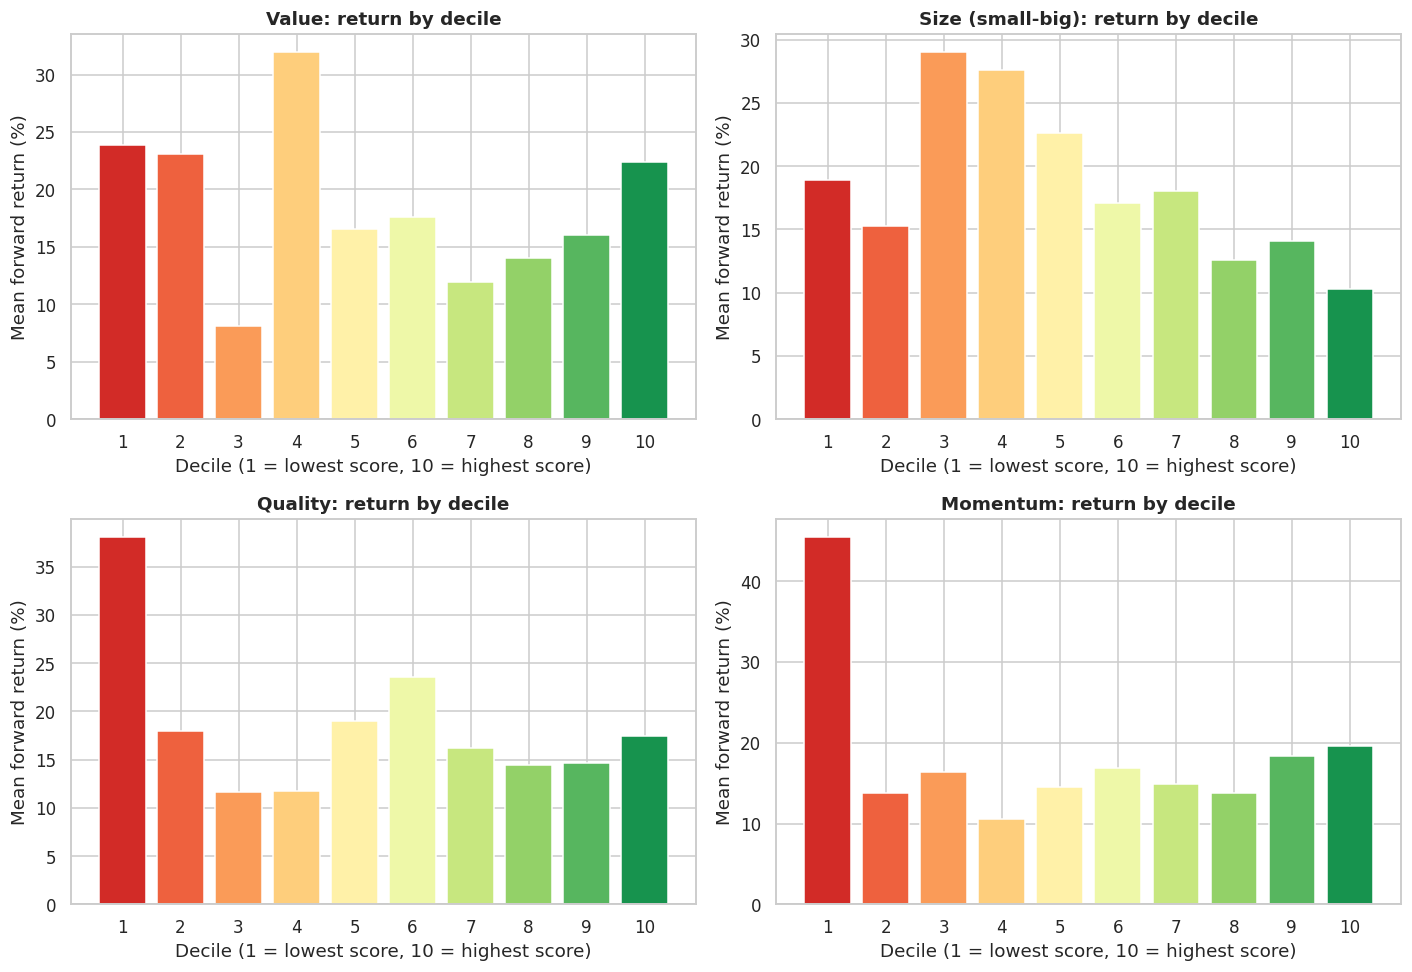

In [8]:
# Define the list of factor columns to analyze.
FACTOR_COLS = ["z_value", "z_size", "z_quality", "z_momentum"]
# Define human-readable labels for each factor for plotting.
FACTOR_LABELS = {"z_value": "Value", "z_size": "Size (small-big)", "z_quality": "Quality", "z_momentum": "Momentum"}

# Create a figure with a 2x2 grid of subplots for decile return plots.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# Iterate through each factor column and its corresponding subplot axis.
for ax, col in zip(axes.flat, FACTOR_COLS):
    # Calculate decile returns for the current factor.
    dret = portfolios.decile_returns(factor_panel, col)
    # Plot the decile returns using the visualization utility.
    viz.plot_decile_returns(dret, FACTOR_LABELS[col], ax=ax)
# Adjust subplot parameters for a tight layout.
fig.tight_layout()
# Save the figure to the 'assets' directory.
fig.savefig("assets/decile_returns.png", dpi=150, bbox_inches="tight")
# Display the plot.
plt.show()

Per-period long-short spreads:


,Value,Size (small-big),Quality,Momentum
period,,,,
2023-07-01,0.062111,-0.168943,0.160427,0.319596
2024-07-01,0.116174,-0.024903,-0.145291,0.003768
2025-07-01,-0.214961,-0.070402,-0.599429,-1.048728


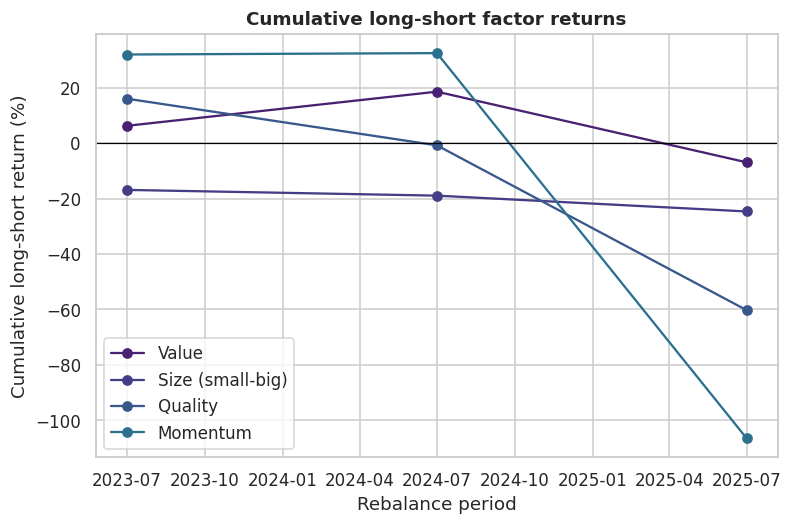

In [9]:
# Calculate long-short spreads for each factor and store them in a dictionary.
spreads = {FACTOR_LABELS[c]: portfolios.long_short_spread(factor_panel, c) for c in FACTOR_COLS}
# Convert the dictionary of spreads into a DataFrame.
spread_df = pd.DataFrame(spreads)
# Set the index name to 'period' for clarity.
spread_df.index.name = "period"
# Print a header for the spreads.
print("Per-period long-short spreads:")
# Display the DataFrame of long-short spreads.
display(spread_df)

# Plot the cumulative long-short performance for all factors.
ax = viz.plot_cumulative_long_short(spreads)
# Save the cumulative long-short plot to the 'assets' directory.
ax.figure.savefig("assets/cumulative_long_short.png", dpi=150, bbox_inches="tight")
# Display the plot.
plt.show()

In [10]:
# Calculate various performance statistics (e.g., annualized return, volatility, Sharpe ratio, max drawdown, hit rate)
# for each factor's long-short spread.
perf = pd.DataFrame({FACTOR_LABELS[c]: portfolios.performance_stats(spreads_c)
                      for c, spreads_c in zip(FACTOR_COLS, spreads.values())})
# Display the transposed DataFrame of performance statistics for better readability.
perf.T

,annualized_return,annualized_vol,sharpe_ratio,max_drawdown,hit_rate,n_periods
Value,-0.023668,0.145045,-0.163175,-0.214961,0.666667,3.0
Size (small-big),-0.090105,0.060118,-1.498800,-0.093552,0.000000,3.0
Quality,-0.264857,0.312176,-0.848421,-0.657628,0.333333,3.0
Momentum,-0.990000,0.584979,-1.692367,-1.048728,0.666667,3.0


## Step 4-5: Fama-MacBeth two-pass regression

**Pass 1**: one cross-sectional OLS per rebalance period,
`fwd_return ~ z_value + z_size + z_quality + z_momentum`. **Pass 2**:
average each factor's coefficient over time; the t-stat tests whether that
average is reliably different from zero given how much it moves period to
period -- the classic Fama-MacBeth (1973) construction.

We then pull **Kenneth French's public data library** (Mkt-RF/SMB/HML/RMW/
CMA/Mom, annual) and compare our estimated premia against French's realized
annual factor returns *over the same sample years* -- not his full
1963-present history, which would make the comparison meaningless.


In [11]:
# Execute the first pass of the Fama-MacBeth regression.
# This involves running a cross-sectional OLS regression for each rebalance period.
# The dependent variable is 'fwd_return' and independent variables are the z-scored factors.
pass1 = regression.fama_macbeth_pass1(factor_panel, FACTOR_COLS)
# Display the results of the first pass, showing coefficients, R-squared, and number of observations per period.
pass1

,n_obs,r_squared,const,z_value,z_size,z_quality,z_momentum
period,,,,,,,
2023-07-01,175,0.214630,0.159355,0.058862,-0.043267,0.016644,0.095681
2024-07-01,191,0.009414,0.140719,0.021338,-0.021176,-0.005398,0.005870
2025-07-01,191,0.119841,0.254041,-0.122689,-0.044425,-0.139125,-0.198905


In [12]:
# Execute the second pass of the Fama-MacBeth regression.
# This involves averaging the coefficients from Pass 1 over time and calculating t-statistics.
# The t-stats indicate if the average factor premium is statistically different from zero.
pass2 = regression.fama_macbeth_pass2(pass1, FACTOR_COLS)
# Display the results of the second pass, including mean premium, standard error, t-stat, and number of periods.
pass2

,mean_premium,std_error,t_stat,n_periods
factor,,,,
const,0.184705,0.035083,5.264801,3
z_value,-0.014163,0.055334,-0.255958,3
z_size,-0.036289,0.007564,-4.797502,3
z_quality,-0.042626,0.048667,-0.875867,3
z_momentum,-0.032451,0.087172,-0.372270,3


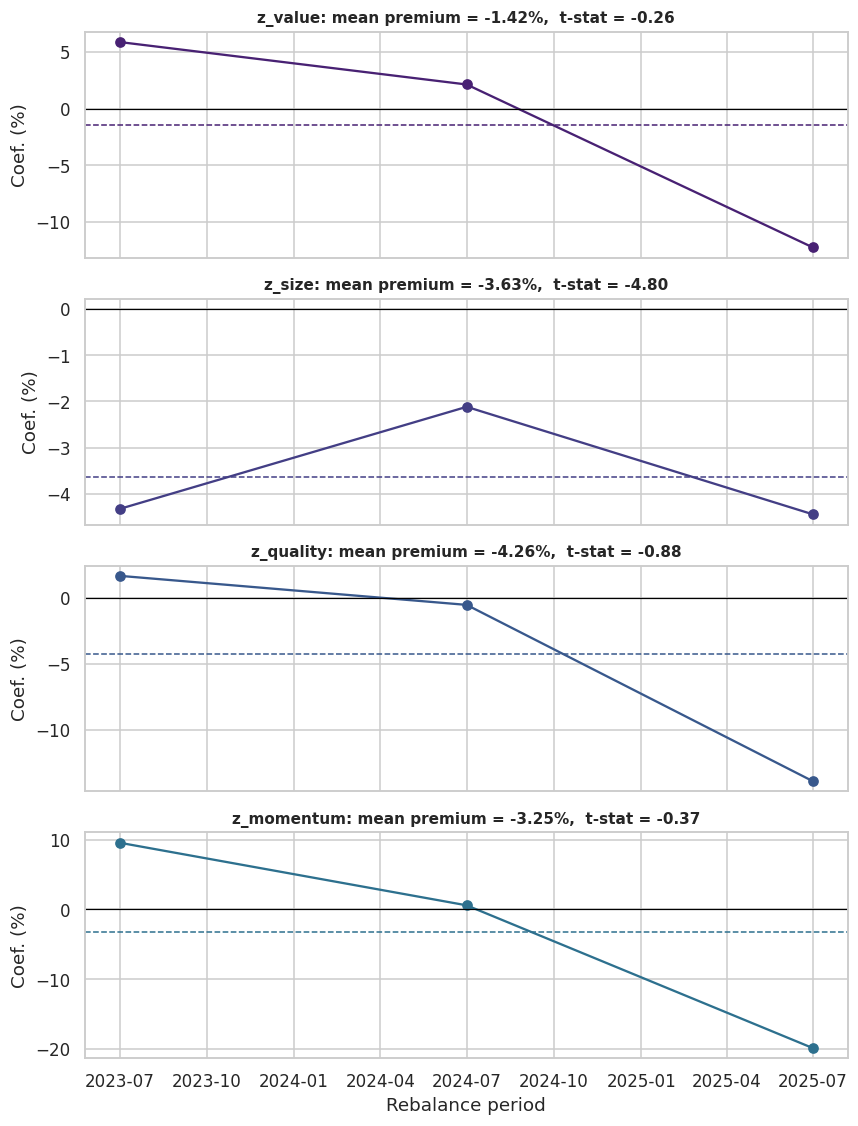

In [13]:
# Plot the Fama-MacBeth regression coefficients, showing the distribution of coefficients from Pass 1
# and the average coefficients with confidence intervals from Pass 2.
fig = viz.plot_fm_coefficients(pass1, FACTOR_COLS, pass2)
# Save the plot to the 'assets' directory.
fig.savefig("assets/fm_coefficients.png", dpi=150, bbox_inches="tight")
# Display the plot.
plt.show()

In [14]:
# Fetch Kenneth French's public factor data (e.g., Mkt-RF, SMB, HML, RMW, CMA, Mom).
french = regression.fetch_french_factors(DATA_DIR)
# Get the unique years present in our factor panel for comparison.
sample_years = sorted(factor_panel["period"].dt.year.unique())
# Compare our estimated factor premia from Fama-MacBeth Pass 2 against Kenneth French's factors.
# This comparison is restricted to the same sample years to ensure a meaningful benchmark.
comparison = regression.compare_to_french(pass2, french, sample_years)
# Print the years used for the comparison.
print(f"Comparing against French's realized annual factors for sample years: {sample_years}")
# Display the comparison results, showing our factor, the corresponding French benchmark, our mean premium,
# our t-statistic, French's mean annual return, and whether the signs of the premia match.
comparison

Comparing against French's realized annual factors for sample years: [np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


,our_factor,ff_benchmark,our_mean_premium,our_t_stat,ff_mean_annual_return,same_sign
0,z_value,HML,-0.014163,-0.255958,-0.043933,True
1,z_size,SMB,-0.036289,-4.797502,-0.097633,True
2,z_quality,RMW,-0.042626,-0.875867,-0.000133,True
3,z_momentum,Mom,-0.032451,-0.372270,-0.021867,True


## Step 6: Composite portfolio

Equal-weighted long the top decile / short the bottom decile of
`z_composite`, backtested over the same rebalance periods, then decomposed
by regressing its period returns on the four single-factor long-short
spreads -- i.e. how much of the composite's return is just its factor
tilts vs. left over as unexplained alpha.


In [15]:
# Calculate the long-short returns for the composite portfolio.
# The composite portfolio is typically formed by going long the top decile and short the bottom decile
# of the overall composite z-score.
composite_returns = portfolios.composite_long_short_returns(factor_panel)
# Convert the Series of composite returns to a DataFrame with a descriptive column name and display it.
composite_returns.to_frame("composite_long_short")

,composite_long_short
period,
2023-07-01,0.177604
2024-07-01,0.041418
2025-07-01,-0.909927


In [16]:
# Calculate various performance statistics (e.g., annualized return, volatility, Sharpe ratio, max drawdown, hit rate)
# for the composite long-short portfolio.
composite_stats = portfolios.performance_stats(composite_returns)
# Display the calculated performance statistics.
composite_stats

,0
annualized_return,-0.520186
annualized_vol,0.483773
sharpe_ratio,-1.075269
max_drawdown,-0.909927
hit_rate,0.666667
n_periods,3.000000


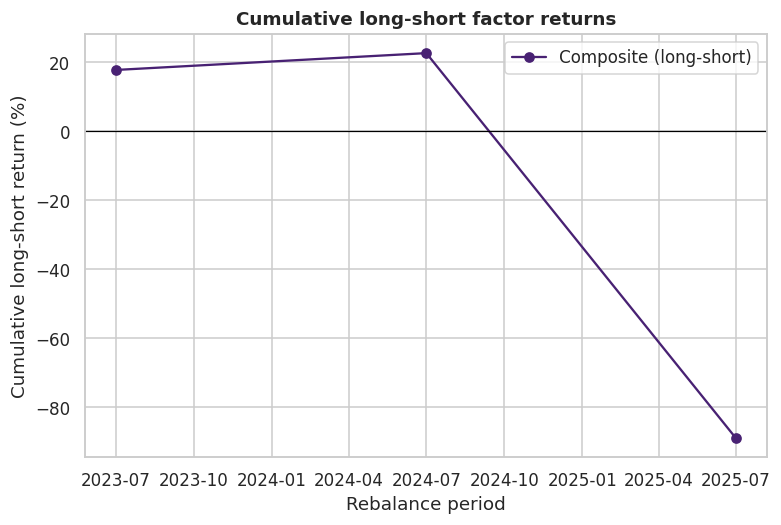

In [17]:
# Plot the cumulative long-short performance of the composite portfolio.
# The input is a dictionary where the key is the label and the value is the Series of returns.
ax = viz.plot_cumulative_long_short({"Composite (long-short)": composite_returns})
# Save the plot to the 'assets' directory.
ax.figure.savefig("assets/composite_cumulative.png", dpi=150, bbox_inches="tight")
# Display the plot.
plt.show()

In [18]:
# Create a DataFrame containing the long-short spread returns for all individual factors.
factor_spread_returns = pd.DataFrame(spreads)
# Decompose the composite portfolio's returns by regressing them against the individual factor spreads.
# This helps to understand how much of the composite's performance is attributable to its exposure to each factor.
loadings, r_squared = portfolios.decompose_returns(composite_returns, factor_spread_returns)
# Print the R-squared value, which indicates the proportion of the composite's return variance explained by the factors.
print(f"R-squared: {r_squared:.3f}  (share of the composite's period-to-period return "
      f"variance explained by the four single-factor spreads)")
# Display the factor loadings, which represent the sensitivity of the composite's returns to each factor spread.
loadings.rename("loading")

R-squared: 1.000  (share of the composite's period-to-period return variance explained by the four single-factor spreads)


,loading
const,-0.022218
Value,0.552533
Size (small-big),0.366161
Quality,-0.039981
Momentum,0.731479


## Step 7: Factor correlation

How correlated are the four factors' cross-sectional z-scores, pooled
across all periods? Low correlation is what makes a multi-factor composite
diversifying rather than redundant.


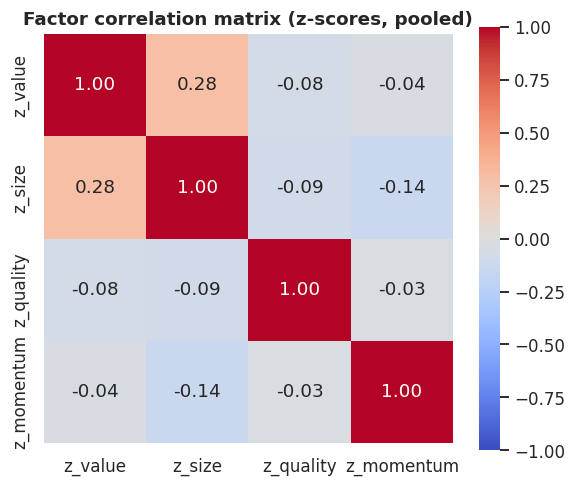

In [19]:
# Plot a correlation heatmap of the cross-sectional z-scores of the factors.
# This visualization helps to understand the relationships and potential diversification benefits between factors.
ax = viz.plot_correlation_heatmap(factor_panel, FACTOR_COLS)
# Save the correlation heatmap to the 'assets' directory.
ax.figure.savefig("assets/correlation_heatmap.png", dpi=150, bbox_inches="tight")
# Display the plot.
plt.show()

## Summary

This notebook pulled real fundamentals + prices for ~190 US equities,
built four independently z-scored cross-sectional factors under explicit
point-in-time constraints, decile-sorted and long-short backtested each
one, estimated their risk premia via Fama-MacBeth and benchmarked those
premia against Kenneth French's public factor library, and combined them
into a composite portfolio decomposed back into its factor exposures.

See `README.md` for the full writeup, including an honest limitations
section covering the annual (not quarterly) rebalance frequency, the
FMP/yfinance blended data sourcing, and the static (survivorship-biased)
universe -- all discovered empirically while building this pipeline against
a real, rate-limited API key rather than assumed away.
